In [2]:
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

In [3]:
# Load CSV file
df = pd.read_csv("dataset_reviews.csv")

#clean column name 
df.columns = df.columns.str.strip()

df

,S.No.,Rating,Product Type,Product,Reviews,Media Attached,App_Reviews,Like_Dislike,Summary,App Source
0,1,1,Home Applinace,Mixer,Disappointed and I have been using it for a few weeks now,1,App is smooth,Dislike,Bad,Amazon
1,2,2,Clothing,Jeans,Not recommended but delivery was late and packaging was average,1,App crashes sometimes,Dsilike,Worst,Ajio
2,3,1,Books,Novel,Very bad experience overall experience could have been better,1,Very user friednly,Dislike,Worst,Amazon
3,4,4,Books,Textbook,Amaznig product overall experience could have been better,1,Needs improvement,Like,Very Good,Amazon
4,5,1,Beauty,Perfume,Poor quality however there are some issues Inoticed,2,Very user friendly,Dislike,Bad,Amazon
...,...,...,...,...,...,...,...,...,...,...
2995,2996,2,Clothing,T-shirt,Not recommended howeevr there are some issues I noticed,0,Good interface,Dislike,Poor,Ajio
2996,2997,3,Electronics,Smartphone,NaN,2,Good interface,Like,Okay,Amazon
2997,2998,5,Colthing,Jeans,Highly recommend and I have been using it for a few weeks now,1,Good interface,Like,Great,Ajio
2998,2999,3,Electronics,Laptop,Not bad overall experience could have been better,1,Good interface,Like,Okay,Flipkart


In [4]:
#converting rate to sentiment 
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

def convert_sentiment(r):
    if pd.isna(r):
        return "Unknown"
    elif r >= 4:
        return "Positive"
    elif r == 3:
        return "Neutral"
    else:
        return "Negative"

df['Sentiments'] = df['Rating'].apply(convert_sentiment)
df

,S.No.,Rating,Product Type,Product,Reviews,Media Attached,App_Reviews,Like_Dislike,Summary,App Source,Sentiments
0,1,1.0,Home Applinace,Mixer,Disappointed and I have been using it for a few weeks now,1,App is smooth,Dislike,Bad,Amazon,Negative
1,2,2.0,Clothing,Jeans,Not recommended but delivery was late and packaging was average,1,App crashes sometimes,Dsilike,Worst,Ajio,Negative
2,3,1.0,Books,Novel,Very bad experience overall experience could have been better,1,Very user friednly,Dislike,Worst,Amazon,Negative
3,4,4.0,Books,Textbook,Amaznig product overall experience could have been better,1,Needs improvement,Like,Very Good,Amazon,Positive
4,5,1.0,Beauty,Perfume,Poor quality however there are some issues Inoticed,2,Very user friendly,Dislike,Bad,Amazon,Negative
...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,2.0,Clothing,T-shirt,Not recommended howeevr there are some issues I noticed,0,Good interface,Dislike,Poor,Ajio,Negative
2996,2997,3.0,Electronics,Smartphone,NaN,2,Good interface,Like,Okay,Amazon,Neutral
2997,2998,5.0,Colthing,Jeans,Highly recommend and I have been using it for a few weeks now,1,Good interface,Like,Great,Ajio,Positive
2998,2999,3.0,Electronics,Laptop,Not bad overall experience could have been better,1,Good interface,Like,Okay,Flipkart,Neutral


In [5]:
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Standardize column names
df.columns = df.columns.str.lower().str.strip()

#handle missing values 
df['rating'].fillna(df['rating'].median(), inplace=True)
df['product type'].fillna("Unknown", inplace=True)
df['product'].fillna("Unknown", inplace=True)
df['reviews'].fillna("No Review", inplace=True)
df['app_reviews'].fillna("No Review", inplace=True)
df['summary'].fillna("No Summary", inplace=True)

#clean like dislike column
df['like_dislike'] = df['like_dislike'].astype(str).str.lower().str.strip()
def clean_like_dislike(x):
    if 'dis' in x:          # covers dsilike, disliek, etc.
        return 'dislike'
    elif 'like' in x:       # covers like, liked, likee
        return 'like'
    else:
        return np.nan       # for ??? or invalid
df['like_dislike'] = df['like_dislike'].apply(clean_like_dislike)
df['like_dislike'] = df['like_dislike'].map({
    'like': 1,
    'dislike': 0
})
df['like_dislike'].fillna(df['like_dislike'].mode()[0], inplace=True)

text_col = 'reviews'
df[text_col] = df[text_col].str.lower()

# remove special characters
df[text_col] = df[text_col].apply(lambda x: re.sub(r'[^a-zA-Z ]', '', str(x)))

# review length feature
df['review_length'] = df[text_col].apply(lambda x: len(x.split()))

# splitting words 
df['tokens'] = df[text_col].apply(lambda x: x.split())

# remove stopwords
stop_words = set(stopwords.words('english'))
df['tokens'] = df['tokens'].apply(
    lambda words: [w for w in words if w not in stop_words]
)
#lemmetization 
lemmatizer = WordNetLemmatizer()
df['tokens'] = df['tokens'].apply(
    lambda words: [lemmatizer.lemmatize(w) for w in words]
)
#clean text 
df['clean_text'] = df['tokens'].apply(lambda x: " ".join(x))

df 


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
C:\Users\user\AppData\Local\Temp\ipykernel_12060\3319853459.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform 

,s.no.,rating,product type,product,reviews,media attached,app_reviews,like_dislike,summary,app source,sentiments,review_length,tokens,clean_text
0,1,1.0,Home Applinace,Mixer,disappointed and i have been using it for a few weeks now,1,App is smooth,0.0,Bad,Amazon,Negative,12,"[disappointed, using, week]",disappointed using week
1,2,2.0,Clothing,Jeans,not recommended but delivery was late and packaging was average,1,App crashes sometimes,1.0,Worst,Ajio,Negative,10,"[recommended, delivery, late, packaging, average]",recommended delivery late packaging average
2,3,1.0,Books,Novel,very bad experience overall experience could have been better,1,Very user friednly,0.0,Worst,Amazon,Negative,9,"[bad, experience, overall, experience, could, better]",bad experience overall experience could better
3,4,4.0,Books,Textbook,amaznig product overall experience could have been better,1,Needs improvement,1.0,Very Good,Amazon,Positive,8,"[amaznig, product, overall, experience, could, better]",amaznig product overall experience could better
4,5,1.0,Beauty,Perfume,poor quality however there are some issues inoticed,2,Very user friendly,0.0,Bad,Amazon,Negative,8,"[poor, quality, however, issue, inoticed]",poor quality however issue inoticed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,2.0,Clothing,T-shirt,not recommended howeevr there are some issues i noticed,0,Good interface,0.0,Poor,Ajio,Negative,9,"[recommended, howeevr, issue, noticed]",recommended howeevr issue noticed
2996,2997,3.0,Electronics,Smartphone,no review,2,Good interface,1.0,Okay,Amazon,Neutral,2,[review],review
2997,2998,5.0,Colthing,Jeans,highly recommend and i have been using it for a few weeks now,1,Good interface,1.0,Great,Ajio,Positive,13,"[highly, recommend, using, week]",highly recommend using week
2998,2999,3.0,Electronics,Laptop,not bad overall experience could have been better,1,Good interface,1.0,Okay,Flipkart,Neutral,8,"[bad, overall, experience, could, better]",bad overall experience could better


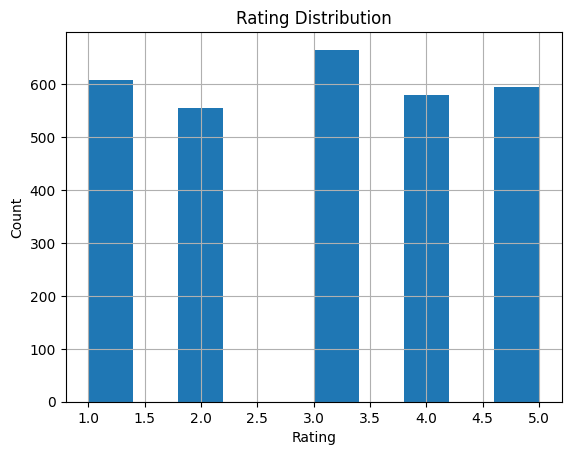

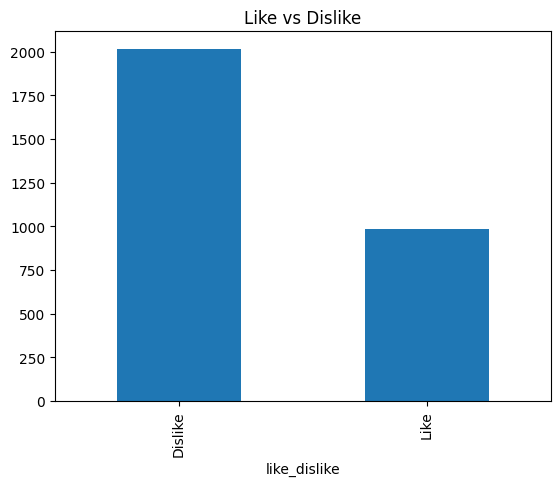

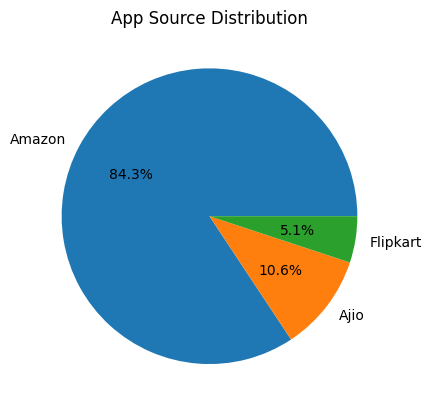

In [6]:
import matplotlib.pyplot as plt

df['rating'].hist()
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

df['like_dislike'].value_counts().plot(kind='bar')
plt.title("Like vs Dislike")
plt.xticks([0,1], ['Dislike','Like'])
plt.show()

# Count values
counts = df['app source'].value_counts()
# Plot pie chart
plt.figure()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("App Source Distribution")
plt.show()

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
import seaborn as sns

X = df['clean_text']
y = df['sentiments']

# tf-idf
tfidf = TfidfVectorizer( 
    max_features=5000, 
    ngram_range=(1,2), 
    stop_words='english' 
)    

X = tfidf.fit_transform(X)

#splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#model
lr_model = LogisticRegression(max_iter=1000)
knn_model = KNeighborsClassifier(n_neighbors=5, metric='cosine')
svm_model = SVC(kernel='linear', probability=True)

# Train
lr_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

#prediction 
y_pred_lr = lr_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

#metrics
def evaluate(y_test, y_pred):
    return [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted')
    ]
lr_metrics = evaluate(y_test, y_pred_lr)
knn_metrics = evaluate(y_test, y_pred_knn)
svm_metrics = evaluate(y_test, y_pred_svm)
#comparision 
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'SVM'],
    'Accuracy': [lr_metrics[0], knn_metrics[0], svm_metrics[0]],
    'Precision': [lr_metrics[1], knn_metrics[1], svm_metrics[1]],
    'Recall': [lr_metrics[2], knn_metrics[2], svm_metrics[2]],
    'F1 Score': [lr_metrics[3], knn_metrics[3], svm_metrics[3]]
})
print("\n Model Comparison:\n")
print(results)




 Model Comparison:

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.741667   0.803589  0.741667  0.734585
1                  KNN  0.721667   0.767536  0.721667  0.713636
2                  SVM  0.736667   0.801209  0.736667  0.729269


C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag